### 필요 라이브러리 설치

### 데이터 읽어오고 기본 확인

데이터셋의 features에 대한 설명은 다음과 같습니다.

mpg = Miles/(US) gallon

cyl = Number of cylinders

disp = Displacement (cu.in.)

hp = Gross horsepower

drat = Rear axle ratio

wt = Weight (lb/1000)

qsec = ¼ mile time

vs = V/S

am = Transmission (0 = automatic, 1 = manual)

gear = Number of forward gears

carb = Number of carburetors

In [3]:
import pandas as pd
df = pd.read_csv("../../../data/mtcars.csv")

In [4]:
df.head()

,Unnamed: 0,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [5]:
df.tail()

,Unnamed: 0,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
27,Lotus Europa,30.4,4,95.1,113,3.77,1.513,16.9,1,1,5,2
28,Ford Pantera L,15.8,8,351.0,264,4.22,3.170,14.5,0,1,5,4
29,Ferrari Dino,19.7,6,145.0,175,3.62,2.770,15.5,0,1,5,6
30,Maserati Bora,15.0,8,301.0,335,3.54,3.570,14.6,0,1,5,8
31,Volvo 142E,21.4,4,121.0,109,4.11,2.780,18.6,1,1,4,2


In [6]:
df.shape

(32, 12)

In [7]:
df.columns

Index(['Unnamed: 0', 'mpg', 'cyl', 'disp', 'hp', 'drat', 'wt', 'qsec', 'vs',
       'am', 'gear', 'carb'],
      dtype='str')

### 누락된 컬럼명 추가

In [8]:
df.rename(columns = {'Unnamed: 0' :'name'}, inplace = True)
df.head()

,name,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


### 추가 정보 탐색

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    32 non-null     str    
 1   mpg     32 non-null     float64
 2   cyl     32 non-null     int64  
 3   disp    32 non-null     float64
 4   hp      32 non-null     int64  
 5   drat    32 non-null     float64
 6   wt      32 non-null     float64
 7   qsec    32 non-null     float64
 8   vs      32 non-null     int64  
 9   am      32 non-null     int64  
 10  gear    32 non-null     int64  
 11  carb    32 non-null     int64  
dtypes: float64(5), int64(6), str(1)
memory usage: 3.1 KB


In [10]:
df.dtypes

name        str
mpg     float64
cyl       int64
disp    float64
hp        int64
drat    float64
wt      float64
qsec    float64
vs        int64
am        int64
gear      int64
carb      int64
dtype: object

In [11]:
df.describe()

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
count,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.000000,32.0000
mean,20.090625,6.187500,230.721875,146.687500,3.596563,3.217250,17.848750,0.437500,0.406250,3.687500,2.8125
std,6.026948,1.785922,123.938694,68.562868,0.534679,0.978457,1.786943,0.504016,0.498991,0.737804,1.6152
min,10.400000,4.000000,71.100000,52.000000,2.760000,1.513000,14.500000,0.000000,0.000000,3.000000,1.0000
25%,15.425000,4.000000,120.825000,96.500000,3.080000,2.581250,16.892500,0.000000,0.000000,3.000000,2.0000
50%,19.200000,6.000000,196.300000,123.000000,3.695000,3.325000,17.710000,0.000000,0.000000,4.000000,2.0000
75%,22.800000,8.000000,326.000000,180.000000,3.920000,3.610000,18.900000,1.000000,1.000000,4.000000,4.0000
max,33.900000,8.000000,472.000000,335.000000,4.930000,5.424000,22.900000,1.000000,1.000000,5.000000,8.0000


In [12]:
len(df['gear'].unique())

3

In [13]:
len(df['am'].unique())

2

## gear, am 조합별 수 구하고 시각화 하기

### pandas.crosstab method를 사용하는 방법
crosstab이란?
엑셀의 피벗과 같이 각 컬럼을 가로/세로로 놓고, 그 수를 세어주는 표.
인자에 넣는 순서에 따라 세로,가로가 정해짐.
가로/세로 내부에 여러 컬럼을 넣어서도 가능.
주요 옵션으로 margins(합계), normalize, values+aggfunc이 있다.

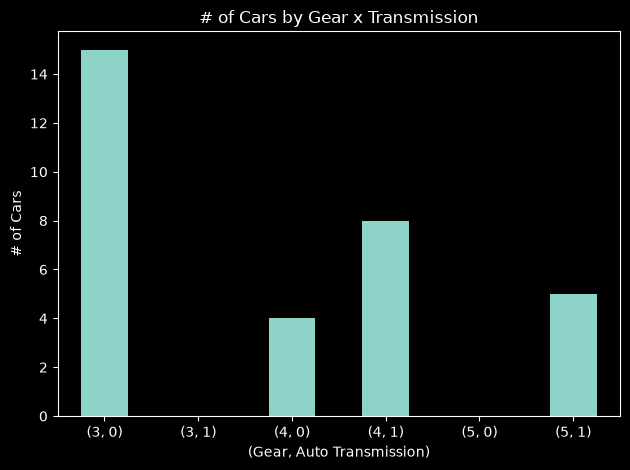

In [14]:
import matplotlib.pyplot as plt

ct = pd.crosstab(df['gear'], df['am']) # .plot(kind='bar')
ct.stack().plot(kind ='bar')
plt.title('# of Cars by Gear x Transmission')
plt.xlabel('(Gear, Auto Transmission)')
plt.ylabel('# of Cars')
plt.xticks(rotation=0) #default : 90
plt.tight_layout()
plt.show()

### pandas.crosstab method를 사용하지 않는 방법

In [15]:
gt = df[['gear', 'am']].value_counts()
gt

gear  am
3     0     15
4     1      8
5     1      5
4     0      4
Name: count, dtype: int64

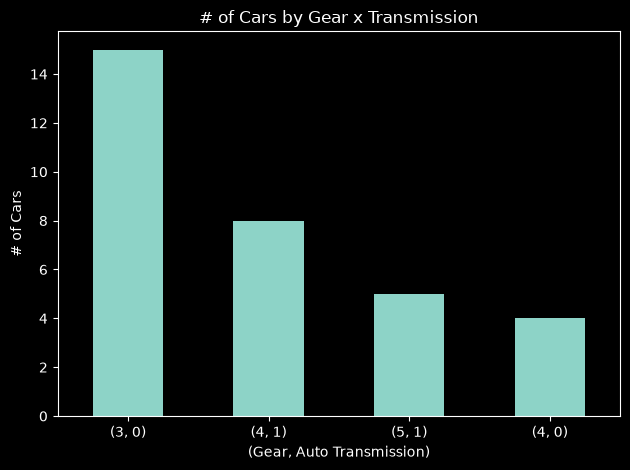

In [16]:
gt.plot(kind='bar')
plt.title('# of Cars by Gear x Transmission')
plt.xlabel('(Gear, Auto Transmission)')
plt.ylabel('# of Cars')
plt.xticks(rotation=0) #default : 90
plt.tight_layout()
plt.show()

### 각 column 별 histogram 그리기 (subplots)

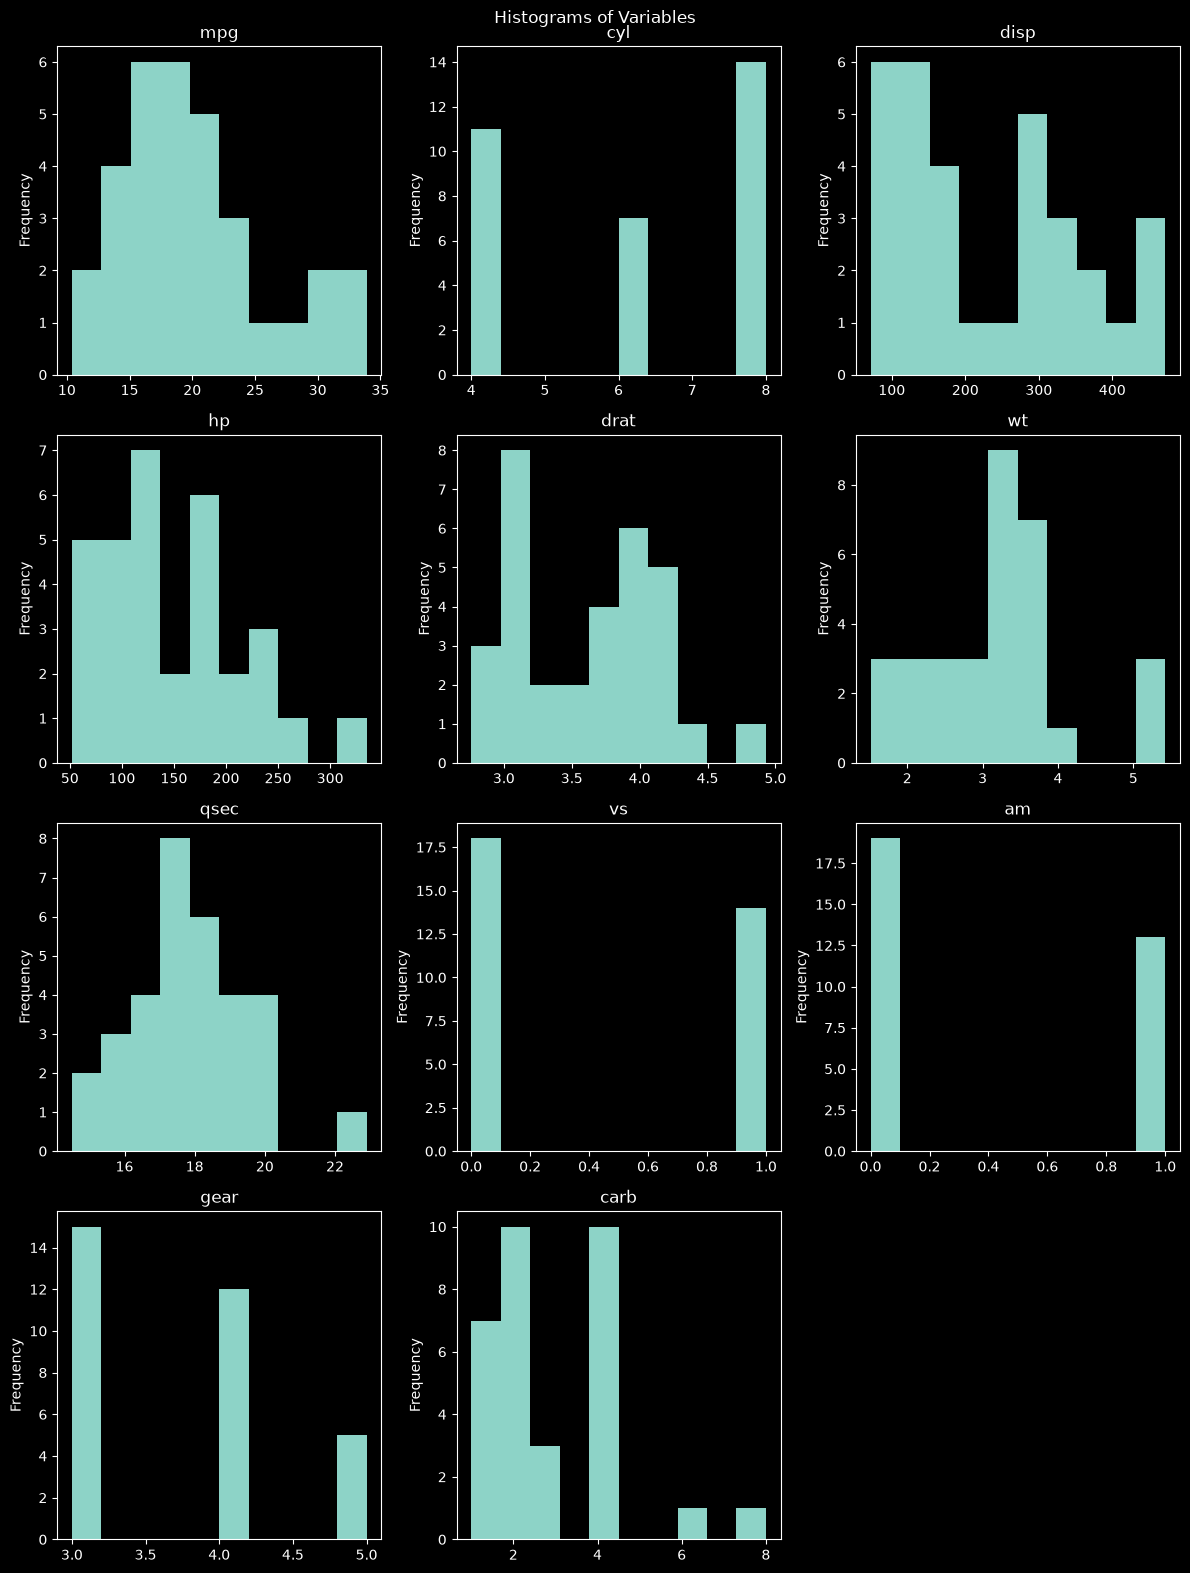

In [17]:
n = len(df.columns)
ncols = 3

corr_df = df.drop(columns='name')
n = len(corr_df.columns)          # ← name 뺀 뒤 다시 세기
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 4*nrows))
for i, col in enumerate(corr_df.columns):
    r, c = i // ncols, i % ncols
    corr_df[col].plot(kind='hist', ax=axes[r][c])
    axes[r][c].set_title(col)

# 루프 끝난 뒤 남는 빈 축 삭제 (바깥으로!)
for j in range(n, nrows * ncols):
    fig.delaxes(axes.flatten()[j])

fig.suptitle('Histograms of Variables')
plt.tight_layout()
plt.show()

### feature간 상관계수 탐색

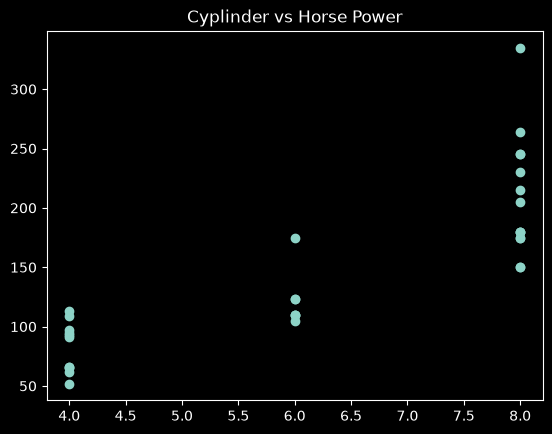

In [18]:
plt.scatter(df['cyl'], df['hp'])
plt.title("Cyplinder vs Horse Power")
plt.show()

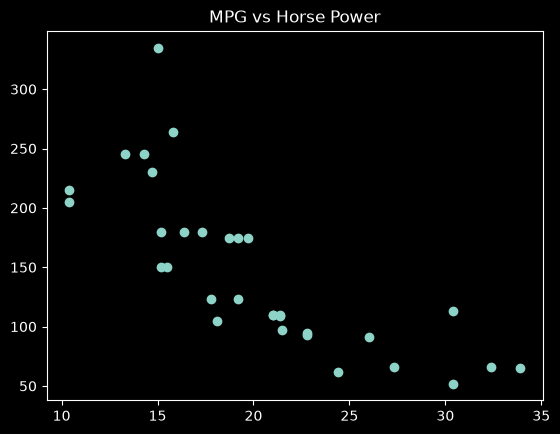

In [19]:
plt.scatter(df['mpg'], df['hp'])
plt.title("MPG vs Horse Power")
plt.show()

In [20]:
corr_df = df.drop(columns = 'name')
corr = corr_df.corr()
corr

,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
mpg,1.000000,-0.852162,-0.847551,-0.776168,0.681172,-0.867659,0.418684,0.664039,0.599832,0.480285,-0.550925
cyl,-0.852162,1.000000,0.902033,0.832447,-0.699938,0.782496,-0.591242,-0.810812,-0.522607,-0.492687,0.526988
disp,-0.847551,0.902033,1.000000,0.790949,-0.710214,0.887980,-0.433698,-0.710416,-0.591227,-0.555569,0.394977
hp,-0.776168,0.832447,0.790949,1.000000,-0.448759,0.658748,-0.708223,-0.723097,-0.243204,-0.125704,0.749812
drat,0.681172,-0.699938,-0.710214,-0.448759,1.000000,-0.712441,0.091205,0.440278,0.712711,0.699610,-0.090790
wt,-0.867659,0.782496,0.887980,0.658748,-0.712441,1.000000,-0.174716,-0.554916,-0.692495,-0.583287,0.427606
qsec,0.418684,-0.591242,-0.433698,-0.708223,0.091205,-0.174716,1.000000,0.744535,-0.229861,-0.212682,-0.656249
vs,0.664039,-0.810812,-0.710416,-0.723097,0.440278,-0.554916,0.744535,1.000000,0.168345,0.206023,-0.569607
am,0.599832,-0.522607,-0.591227,-0.243204,0.712711,-0.692495,-0.229861,0.168345,1.000000,0.794059,0.057534
gear,0.480285,-0.492687,-0.555569,-0.125704,0.699610,-0.583287,-0.212682,0.206023,0.794059,1.000000,0.274073


이런 데이터셋을 분석해서 얻을 수 있는 경제적 가치는 무엇일까요? 어떤 비즈니스 상황에서 이런 데이터셋을 분석해서 어떤 경제적 가치를 얻을 수 있을까요?

변수들 간의 상관 관계가 높은 조합을 임의로 2개 선택해서 해당 데이터 간의 상관 관계를 그래프로 그리고 어떤 결론을 내릴 수 있는지를 토의하세요.

해당 내용을 팀위키에 기록하고 제출하세요.

In [22]:
import numpy as np

# 상삼각만 남기기 (대각선 + 하삼각 제거)
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# 절댓값 기준 상위 2개
top2 = upper.unstack().dropna().abs().sort_values(ascending=False).head(2)
print(top2)

disp  cyl     0.902033
wt    disp    0.887980
dtype: float64


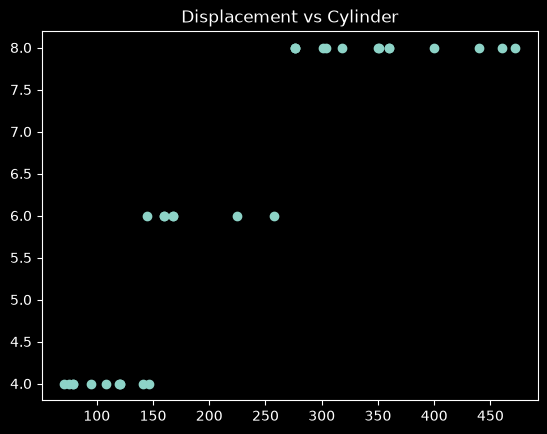

In [23]:
plt.scatter(df['disp'], df['cyl'])
plt.title("Displacement vs Cylinder")
plt.show()

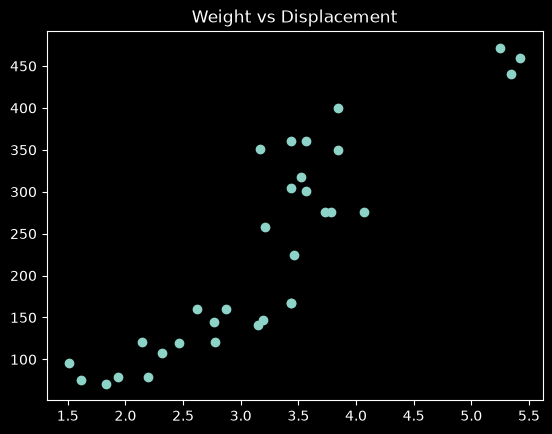

In [24]:
plt.scatter(df['wt'], df['disp'])
plt.title("Weight vs Displacement")
plt.show()

실린더 개수가 많아지고, 무게가 커질수록 배기량이 많아지고.
배기량이 많아질수록 연비가 낮아진다.